## EDA and Data Loading

In [3]:
import pandas as pd
import numpy as np
import kagglehub

path = kagglehub.dataset_download("andrewmvd/early-diabetes-classification")
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load directly into DataFrame
df = pd.read_csv(f"{path}/diabetes_data.csv", sep=';')
df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,Male,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,Male,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,Male,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,Male,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,Male,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [4]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})  # Encoding Gender
X_pima = df.drop('class', axis=1)
y_pima = df['class'] # Already 0 and 1, no mapping needed

print(f"Target Values: {y_pima.unique()}")
print(f"Data Shape: {X_pima.shape}")

X = X_pima
y = y_pima.rename('diagnosis') # Renaming 
target_names = np.array(['No Diabetes', 'Diabetes'])
df = pd.concat([X, y], axis=1)


Target Values: [1 0]
Data Shape: (520, 16)


In [5]:
#observing head
df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,diagnosis
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


## Alternative Dataset: Andrewmvd early diabetes classification
For comparison purposes, we can load the **Early Diabetes Classification** data. This is another classic binary classification dataset where the goal is to predict whether a patient has diabetes based on diagnostic measurements.


In [8]:
# checking for missing values, shape and data types
print("---DataFrame Shape---", df.shape)
print("\n---Data Types---\n", df.dtypes)
print("\n---Missing Values---\n", df.isnull().sum())
print("\n--unique values in each column--")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

---DataFrame Shape--- (520, 17)

---Data Types---
 age                   int64
gender                int64
polyuria              int64
polydipsia            int64
sudden_weight_loss    int64
weakness              int64
polyphagia            int64
genital_thrush        int64
visual_blurring       int64
itching               int64
irritability          int64
delayed_healing       int64
partial_paresis       int64
muscle_stiffness      int64
alopecia              int64
obesity               int64
diagnosis             int64
dtype: object

---Missing Values---
 age                   0
gender                0
polyuria              0
polydipsia            0
sudden_weight_loss    0
weakness              0
polyphagia            0
genital_thrush        0
visual_blurring       0
itching               0
irritability          0
delayed_healing       0
partial_paresis       0
muscle_stiffness      0
alopecia              0
obesity               0
diagnosis             0
dtype: int64

--unique value

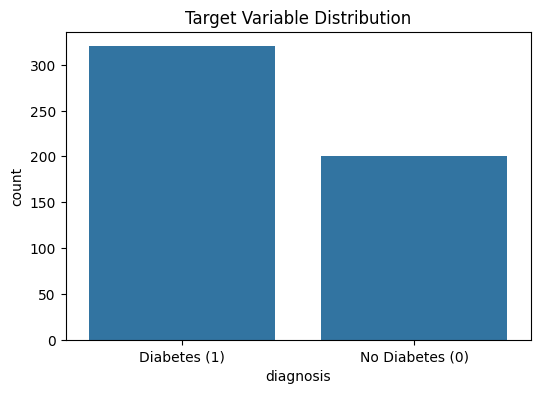

diagnosis
1    0.615385
0    0.384615
Name: proportion, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# checking if the classes are balanced
plt.figure(figsize=(6, 4))
sns.countplot(x=y.map({0: 'No Diabetes (0)', 1: 'Diabetes (1)'}))
plt.title('Target Variable Distribution')
plt.show()

print(y.value_counts(normalize=True))

## Data Preprocessing

We'll create a `Pipeline` that first scales the data using `StandardScaler` and then runs the model.

From there, we will create pipelines for our models, build, train, and get baseline results.



In the paper, the authors implement SMOTE rebalancing for the classes, we include this in our pipelein.

X_train shape: (364, 16)
X_test shape: (156, 16)
y_train shape: (364,)
y_test shape: (156,)


After SMOTE (train) counts of label '1': 224
After SMOTE (train) counts of label '0': 224 



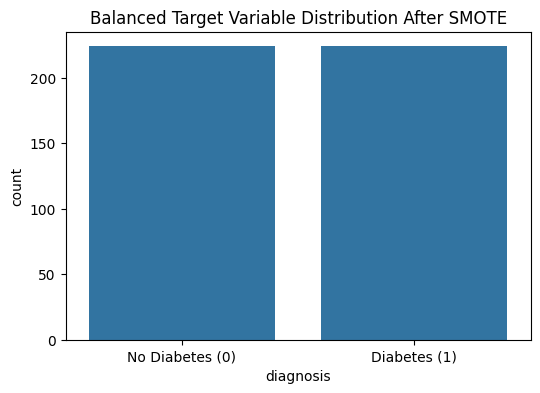

In [11]:
from sklearn.model_selection import train_test_split

# we are doing a 70/30 split of the data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# %pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE (train) counts of label '1': {}".format(sum(y_train_res==1)))
print("After SMOTE (train) counts of label '0': {} \n".format(sum(y_train_res==0)))

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_res.map({0: 'No Diabetes (0)', 1: 'Diabetes (1)'}))
plt.title('Balanced Target Variable Distribution After SMOTE')
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler

,copy,True
,with_mean,True
,with_std,True


## Model Implementation

We observe the AUC for this binary classification task, since data is discrete, we consider the AUC values to test the predictive value of each variable instead of $R^2$

--- Univariate Logistic AUC (using SMOTE resampled train) ---
               Feature       AUC
2             polyuria  0.841518
3           polydipsia  0.837054
4   sudden_weight_loss  0.745536
1               gender  0.727679
12     partial_paresis  0.718750
6           polyphagia  0.671875
5             weakness  0.633929
14            alopecia  0.631696
10        irritability  0.613839
8      visual_blurring  0.613839
0                  age  0.564961
7       genital_thrush  0.558036
15             obesity  0.537946
13    muscle_stiffness  0.529018
11     delayed_healing  0.515625
9              itching  0.500000


C:\Users\edgar\AppData\Local\Temp\ipykernel_7568\3913511878.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AUC', y='Feature', data=auc_df, palette='viridis')


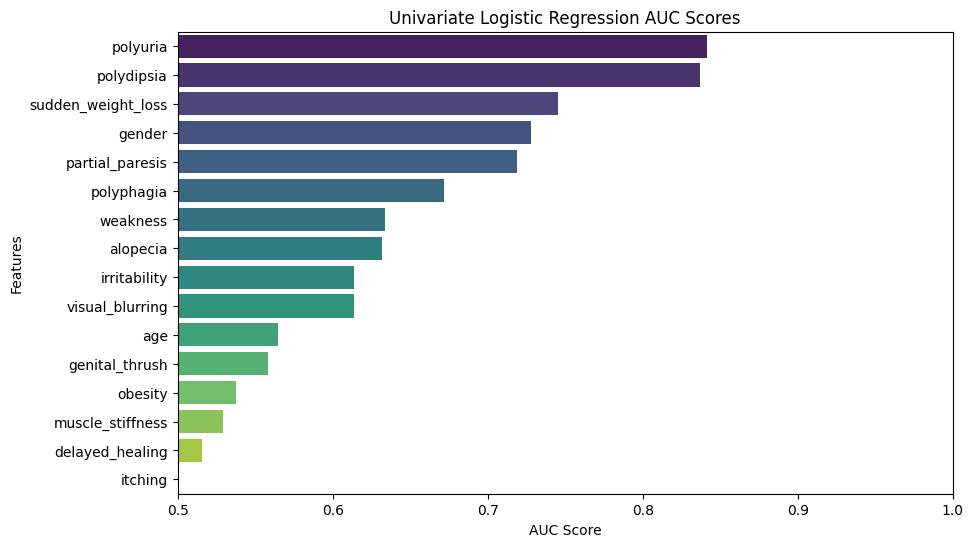

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

auc_results = []
print("--- Univariate Logistic AUC (using SMOTE resampled train) ---")
for feature in X_train_res.columns:
    lr = LogisticRegression(solver='liblinear')
    X_feat = X_train_res[[feature]]
    lr.fit(X_feat, y_train_res)
    proba = lr.predict_proba(X_feat)[:, 1]
    auc = roc_auc_score(y_train_res, proba)
    auc_results.append({'Feature': feature, 'AUC': auc})

auc_df = pd.DataFrame(auc_results).sort_values(by='AUC', ascending=False)
print(auc_df)

# plotting the auc
plt.figure(figsize=(10, 6))
sns.barplot(x='AUC', y='Feature', data=auc_df, palette='viridis')
plt.title('Univariate Logistic Regression AUC Scores')
plt.xlabel('AUC Score')
plt.ylabel('Features')
plt.xlim(0.5, 1)
plt.show()

### K-NN

We have previously implemented the same GLM, SVM, and SVM RBF models on similar data.

According to "Data-Driven Machine-Learning Methods for Diabetes Risk Prediction" by Elias DritsasORCID and Maria Trigka, a variety of models were tested on a different diabetes dataset.
In this file, we implement the same models to evaluate performance on binary data and evaluate their performance, as well as integrate new  models that could perhaps perform better.

### Logistic Regression

Creating a pipeling for logistic regression, train the model and evaluate

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, solver= 'liblinear'))
])

# training
lr_pipeline.fit(X_train_res, y_train_res)

# get predictions on the test set
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# calculating metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("--- Logistic Regression Test Results ---")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"AUC: {auc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=target_names))


--- Logistic Regression Test Results ---
Accuracy: 0.9231
AUC: 0.9700

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.85      0.97      0.91        60
    Diabetes       0.98      0.90      0.93        96

    accuracy                           0.92       156
   macro avg       0.92      0.93      0.92       156
weighted avg       0.93      0.92      0.92       156



### SVM

We will create a pipeline for linear SVM, train, and evaluate the model

In [18]:
from sklearn.svm import SVC

svm_linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # using a new instance of scaler
    ('svm_linear', SVC(kernel='linear', probability=True, random_state=42))
])

# training the model
svm_linear_pipeline.fit(X_train_res, y_train_res)

# evaluating the linear svm and checking performance agains the logisitic regression model
y_pred_svm_linear = svm_linear_pipeline.predict(X_test)
y_proba_svm_linear = svm_linear_pipeline.predict_proba(X_test)[:, 1]

# calculating metrics
accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
auc_svm_linear = roc_auc_score(y_test, y_proba_svm_linear)

print("--- Linear SVM Test Results ---")
print(f"Accuracy: {accuracy_svm_linear:.4f}")
print(f"AUC: {auc_svm_linear:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_linear, target_names=target_names))


--- Linear SVM Test Results ---
Accuracy: 0.9295
AUC: 0.9687

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.87      0.97      0.91        60
    Diabetes       0.98      0.91      0.94        96

    accuracy                           0.93       156
   macro avg       0.92      0.94      0.93       156
weighted avg       0.93      0.93      0.93       156



### Non-Linear Kernel (RBF)
Implementing a Non-linear kernel (RBF) and using GridSearchCV to find the best ```C``` and ```gamma``` parameters.

In [25]:
from sklearn.model_selection import GridSearchCV

# creating a pipeline for RBF SVM
svm_rbf_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # using a new instance of scaler
    ('svm_rbf', SVC(kernel='rbf', probability=True, random_state=42))
])

# defining parameter grid for GridSearchCV
param_grid = {
    'svm_rbf__C': [0.1, 1, 5, 10, 10.1, 10.2, 10.3],
    'svm_rbf__gamma': [1.3, 1.31, 1.32, 1.33, 1.34, 1.35, 1.4, 1.5]
}

# setting up GridSearchCV to find the best parameters using 5-fold cross-validation
svm_grid = GridSearchCV(svm_rbf_pipeline, param_grid, refit=True, verbose=2, cv=5, scoring='roc_auc')

# train the model (gridsearchcv will find the best model parameters and retrain it on all training data)
svm_grid.fit(X_train_res, y_train_res)
print(f"Best Parameters from GridSearchCV: {svm_grid.best_params_}")


Fitting 5 folds for each of 56 candidates, totalling 280 fits
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=1.3; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=1.3; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=1.3; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=1.3; total time=   0.0s
[CV] END .................svm_rbf__C=0.1, svm_rbf__gamma=1.3; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rbf__gamma=1.31; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rbf__gamma=1.31; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rbf__gamma=1.31; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rbf__gamma=1.31; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rbf__gamma=1.31; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rbf__gamma=1.32; total time=   0.0s
[CV] END ................svm_rbf__C=0.1, svm_rb

In [26]:
# Now w will make predictions and evaluate the model
y_pred_svm_rbf = svm_grid.predict(X_test)
y_proba_svm_rbf = svm_grid.predict_proba(X_test)[:, 1]

# calculating metrics
accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
auc_svm_rbf = roc_auc_score(y_test, y_proba_svm_rbf)

print("--- RBF SVM Test Results ---")
print(f"Accuracy: {accuracy_svm_rbf:.4f}")
print(f"AUC: {auc_svm_rbf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_rbf, target_names=target_names))

--- RBF SVM Test Results ---
Accuracy: 0.9551
AUC: 0.9991

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       1.00      0.88      0.94        60
    Diabetes       0.93      1.00      0.96        96

    accuracy                           0.96       156
   macro avg       0.97      0.94      0.95       156
weighted avg       0.96      0.96      0.95       156



## Model Comparison and Evaluation

In [27]:
from sklearn.metrics import confusion_matrix

def get_metrics(y_true, y_pred, y_proba, target_names):
    '''
    Calculates accuracy, auc, sensitivity, and specificity.
    '''
    
    # getting values from the confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    # Sensitivity (Recall) = How many Diabetes cases did we find? (Higher is better)
    # This directly measures our goal of minimizing False Negatives.
    sensitivity = tp / (tp + fn) 

    # Specificity = How many Non-Diabetes cases did we correctly identify? (Higher is better)
    # This measures how well we avoid False Positives.
    specificity = tn / (tn + fp)  

    # getting raw counts
    false_negatives = fn
    false_positives = fp

    
    return {
        'Accuracy': accuracy,
        'AUC': auc,
        'Sensitivity (Diabetes Recall)': sensitivity,
        'Specificity (Non-Diabetes Recall)': specificity,
        'False Negatives (FN)': false_negatives,
        'False Positives (FP)': false_positives
    }

In [28]:
# getting metics for all models
metrics_lr = get_metrics(y_test, y_pred_lr, y_proba_lr, target_names)
metrics_svm_linear = get_metrics(y_test, y_pred_svm_linear, y_proba_svm_linear, target_names)
metrics_svm_rbf = get_metrics(y_test, y_pred_svm_rbf, y_proba_svm_rbf, target_names)

# creating a comparison df
comparison_df = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'SVM Linear': metrics_svm_linear,
    'SVM RBF (Tuned)': metrics_svm_rbf
})

print("--- Model Performance Comparison ---")
print(comparison_df)

comparison_df

--- Model Performance Comparison ---
                                   Logistic Regression  SVM Linear  \
Accuracy                                      0.923077    0.929487   
AUC                                           0.969965    0.968750   
Sensitivity (Diabetes Recall)                 0.895833    0.906250   
Specificity (Non-Diabetes Recall)             0.966667    0.966667   
False Negatives (FN)                         10.000000    9.000000   
False Positives (FP)                          2.000000    2.000000   

                                   SVM RBF (Tuned)  
Accuracy                                  0.955128  
AUC                                       0.999132  
Sensitivity (Diabetes Recall)             1.000000  
Specificity (Non-Diabetes Recall)         0.883333  
False Negatives (FN)                      0.000000  
False Positives (FP)                      7.000000  


,Logistic Regression,SVM Linear,SVM RBF (Tuned)
Accuracy,0.923077,0.929487,0.955128
AUC,0.969965,0.968750,0.999132
Sensitivity (Diabetes Recall),0.895833,0.906250,1.000000
Specificity (Non-Diabetes Recall),0.966667,0.966667,0.883333
False Negatives (FN),10.000000,9.000000,0.000000
False Positives (FP),2.000000,2.000000,7.000000


### 10-fold CV on different models

According to "Data-Driven Machine-Learning Methods for Diabetes Risk Prediction" by Elias DritsasORCID and Maria Trigka, a variety of models were tested to compare their performance on this same data. We will recreate this exercise.

One thing to consider is the rebalancing using SMOTE to prevent leakage.

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline 

# Define the cross-validation strategy (10-Fold)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'SVM Linear': SVC(kernel='linear', probability=True, random_state=42),
    'SVM RBF (Tuned)': SVC(kernel='rbf', C=10, gamma=1.3, probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB()
}

scoring_metrics = {
    'accuracy': 'accuracy',
    'auc': 'roc_auc',
    'sensitivity': 'recall',
    'precision': 'precision'
}

In [31]:
results_list = []

print(f"{'Model':<25} {'Mean Accuracy':<15} {'Mean AUC':<10} {'Mean Sensitivity':<15}")
print("-" * 65)

for name, model in models.items():
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    cv_results = cross_validate(
        pipeline, 
        X_train, 
        y_train, 
        cv=cv, 
        scoring=scoring_metrics,
        n_jobs=-1
    )
    
    mean_acc = cv_results['test_accuracy'].mean()
    mean_auc = cv_results['test_auc'].mean()
    mean_sens = cv_results['test_sensitivity'].mean()
    
    print(f"{name:<25} {mean_acc:.4f}          {mean_auc:.4f}     {mean_sens:.4f}")
    
    results_list.append({
        'Model': name,
        'Accuracy': mean_acc,
        'AUC': mean_auc,
        'Sensitivity': mean_sens,
        'Precision': cv_results['test_precision'].mean()
    })

Model                     Mean Accuracy   Mean AUC   Mean Sensitivity
-----------------------------------------------------------------
Logistic Regression       0.9204          0.9712     0.9109
SVM Linear                0.9396          0.9678     0.9466
SVM RBF (Tuned)           0.9148          0.9900     0.9866
KNN                       0.9036          0.9859     0.8698
Random Forest             0.9670          0.9991     0.9597
Naive Bayes               0.8736          0.9522     0.8927



--- Detailed 10-Fold CV Results (Sorted by Sensitivity) ---


,Model,Accuracy,AUC,Sensitivity,Precision
2,SVM RBF (Tuned),0.914790,0.990006,0.986561,0.891105
4,Random Forest,0.967042,0.999054,0.959684,0.987652
1,SVM Linear,0.939565,0.967758,0.946640,0.955929
0,Logistic Regression,0.920420,0.971189,0.910870,0.958533
5,Naive Bayes,0.873574,0.952167,0.892688,0.906522
3,KNN,0.903604,0.985870,0.869763,0.973085


C:\Users\edgar\AppData\Local\Temp\ipykernel_7568\1758664178.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=cv_df, ax=axes[0], palette='viridis')
C:\Users\edgar\AppData\Local\Temp\ipykernel_7568\1758664178.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC', data=cv_df, ax=axes[1], palette='magma')
C:\Users\edgar\AppData\Local\Temp\ipykernel_7568\1758664178.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Sensitivity', data=cv_df, ax=axes[2], palette='rocket')


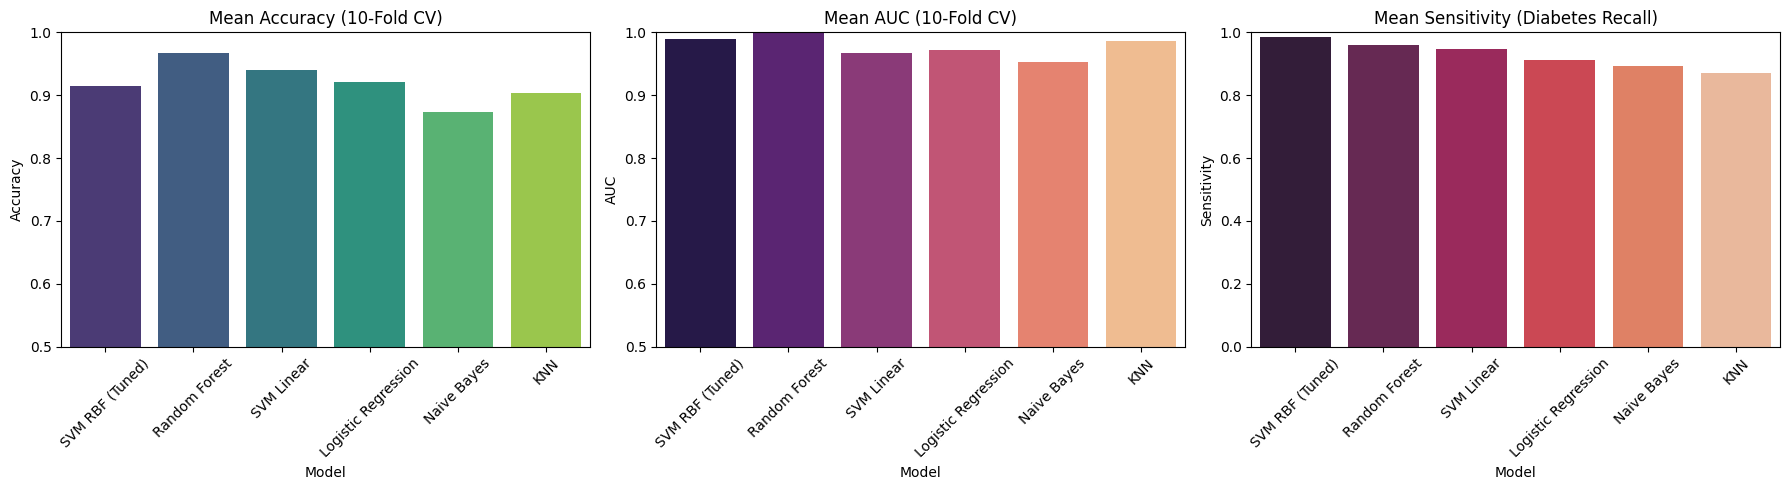

In [32]:
# Create a DataFrame for easy comparison
cv_df = pd.DataFrame(results_list).sort_values(by='Sensitivity', ascending=False)

print("\n--- Detailed 10-Fold CV Results (Sorted by Sensitivity) ---")
display(cv_df)

# Plotting the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Model', y='Accuracy', data=cv_df, ax=axes[0], palette='viridis')
axes[0].set_title('Mean Accuracy (10-Fold CV)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0.5, 1.0)

sns.barplot(x='Model', y='AUC', data=cv_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean AUC (10-Fold CV)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0.5, 1.0)

sns.barplot(x='Model', y='Sensitivity', data=cv_df, ax=axes[2], palette='rocket')
axes[2].set_title('Mean Sensitivity (Diabetes Recall)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()